# imageseg: Deep Learning-Based Image Segmentation of Canopy Photographs (pre-trained model demo)

**Paper:** Niedballa, J., Axtner, J., & Leibniz Institute for Zoo and Wildlife Research (2022).
*imageseg: An R package for deep learning-based image segmentation.*
Methods in Ecology and Evolution, 13(11), 2363–2371. https://doi.org/10.1111/2041-210X.13984

**Author code:** R package `imageseg` v0.5.2 (MIT), pinned commit
`bba7a54c174308cc3800ad59568c9c928db74694` — https://github.com/EcoDynIZW/imageseg (also on CRAN).
**Model weights:** Zenodo record 6861157 (`imageseg_canopy_model.zip`, 101,009,262 bytes, md5 `3b466d066a1407d04b0627818ad5372f`).

## What this notebook does / 実行内容

**English**
- Runs the **author's own R workflow** (vignette Part 1: `resizeImages → loadImages → imagesToKerasInput → loadModel → imageSegmentation`) to apply the **pre-trained canopy model** to the example canopy images **bundled in the R package** (3 raw JPGs; plus 11 pre-resized 256×256 images with author hand-masks).
- Computes **canopy density / sky fraction** per image (`results$summary`).
- Adds **our own plausibility check** (not a paper evaluation): per-image **Dice coefficient** between the model's binary prediction and the author's hand-drawn masks for the 11 bundled images. The paper reports canopy Dice ≈ 0.91 on its held-out test set; this 11-image check is only a sanity check, not a reproduction of that number.

**日本語**
- 著者自身の R ワークフロー（ビネット Part 1）をそのまま実行し、訓練済み canopy モデルをパッケージ同梱のサンプル画像に適用します。
- 各画像の canopy density（= 1 − sky 比率）を `results$summary` として出力します。
- さらに**このノートブック独自の確認**として、著者提供の手描きマスクとモデル予測の Dice 係数を 11 枚の同梱画像で計算します。論文のテストセット Dice ≈ 0.91 の再現ではなく、あくまで妥当性のスポットチェックです。

## Scope and status / スコープと実行状況
- **Partial demonstration — pre-trained inference only.** Training (vignette Part 2), the understory model, threshold comparisons, and dataset-level accuracy evaluation are **out of scope**.
- Runtime: **CPU only** (the paper states CPU prediction is practical; 11 images at 256×256 take seconds — the setup/installs dominate the runtime).
- Estimated end-to-end time: ~15–25 min, dominated by downloads/installs (~700 MB: R binaries, TensorFlow CPU wheel 230 MB, model zip 101 MB).
- The authors did not provide this Colab notebook; it is an AI-authored, faithful **invocation of the authors' R implementation** in headless R on Colab (Python is only the launcher that calls `Rscript`). All downloads and computation happen inside this Colab VM.

## Runtime selection / ランタイムの選択

**Select Runtime → Change runtime type → CPU (recommended).** No GPU is needed: the paper explicitly reports CPU-only prediction (~100 canopy images/min on an i7-7500U laptop), and our workload is 14 images at 256×256 through a small U-Net.

**Run all** (`ランタイム → すべてのセルを実行`) runs the whole notebook. It installs R packages (Posit Package Manager binaries + pinned `keras`/`tensorflow` R 2.15.0 from the CRAN Archive), creates a Python 3.11 environment with `tensorflow-cpu==2.15.1`, downloads the model from Zenodo, and runs the author's R workflow twice (3 raw images; 11 pre-resized images + Dice check).

**CPU を選択してください。GPU は不要です（論文も CPU 推論を前提としています）。すべてのセルを実行すると、セットアップから結果表示まで一括で完了します（目安 15–25 分）。**

### Environment report / 環境の確認

Check the base environment of the Colab VM: OS, the system R (`Rscript`), Python, CPU count and RAM. The author's implementation is R, so we verify R exists before installing anything. R の存在と CPU/メモリを確認します。

In [ ]:
import subprocess

probe = r"""
echo "== OS =="
. /etc/os-release && echo "$PRETTY_NAME"
echo "== R =="
/usr/bin/Rscript -e 'cat(R.version.string)'
echo ""
echo "== Python =="
python3 --version
echo "== CPU / RAM =="
nproc
free -g | sed -n '2p'
"""
subprocess.run(["bash", "-c", probe], check=True, timeout=300)

CompletedProcess(args=['bash', '-c', '\necho "== OS =="\n. /etc/os-release && echo "$PRETTY_NAME"\necho "== R =="\n/usr/bin/Rscript -e \'cat(R.version.string)\'\necho ""\necho "== Python =="\npython3 --version\necho "== CPU / RAM =="\nnproc\nfree -g | sed -n \'2p\'\n'], returncode=0)

### Install R packages (pinned) / R パッケージのインストール

Installs the R dependencies of `imageseg` (including `imageseg` itself) as **Posit Package Manager (P3M) Ubuntu binaries** first, and **then** force-pins the **last R `keras`/`tensorflow` versions that provide `keras::load_model_hdf5` (2.15.0)** from the CRAN Archive — `imageseg` 0.5.2 imports it, R keras 3.x/2.16 removed or changed it, and the P3M dependency resolution would otherwise upgrade `keras` past 2.15 (observed: imageseg install pulled keras 2.16.1, breaking model loading — hence pinning *last*). System libraries for `magick` are installed via apt. `imageseg` は CRAN 0.5.2（同梱サンプル画像付き）。`keras` R は `load_model_hdf5` を提供する最終版 2.15.0 に**最後に**固定します（P3M の依存解決が keras を 2.16 に上げてしまうため）。

In [ ]:
setup_r = r"""
set -e
. /etc/os-release
case "$VERSION_ID" in
  24.04) CN=noble ;;
  *)     CN=jammy ;;
esac
P3M="https://packagemanager.posit.co/cran/__linux__/${CN}/latest"
echo "Using P3M binary repo: $P3M"
export DEBIAN_FRONTEND=noninteractive
apt-get update -qq
apt-get install -y -qq libmagick++-dev libcurl4-openssl-dev libssl-dev libxml2-dev
Rscript -e "options(HTTPUserAgent=sprintf('R (%s)', getRversion()), repos=c(P3M='$P3M'), Ncpus=2); install.packages(c('Rcpp','magick','tibble','purrr','dplyr','foreach','doParallel','magrittr','jsonlite','reticulate','rlang','glue','zeallot','generics','tfruns','config','png','imageseg'))"
echo "--- force-pin keras/tensorflow R 2.15.0 from CRAN Archive (AFTER imageseg) ---"
Rscript -e "install.packages('https://cran.r-project.org/src/contrib/Archive/tensorflow/tensorflow_2.15.0.tar.gz', repos=NULL, type='source')"
Rscript -e "install.packages('https://cran.r-project.org/src/contrib/Archive/keras/keras_2.15.0.tar.gz', repos=NULL, type='source')"
Rscript -e "cat('imageseg:', as.character(packageVersion('imageseg')), '| keras:', as.character(packageVersion('keras')), '| tensorflow:', as.character(packageVersion('tensorflow')), '
')"
"""
subprocess.run(["bash", "-c", setup_r], check=True, timeout=3600)

CompletedProcess(args=['bash', '-c', '\nset -e\n. /etc/os-release\ncase "$VERSION_ID" in\n  24.04) CN=noble ;;\n  *)     CN=jammy ;;\nesac\nP3M="https://packagemanager.posit.co/cran/__linux__/${CN}/latest"\necho "Using P3M binary repo: $P3M"\nexport DEBIAN_FRONTEND=noninteractive\napt-get update -qq\napt-get install -y -qq libmagick++-dev libcurl4-openssl-dev libssl-dev libxml2-dev\nRscript -e "options(HTTPUserAgent=sprintf(\'R (%s)\', getRversion()), repos=c(P3M=\'$P3M\'), Ncpus=2); install.packages(c(\'Rcpp\',\'magick\',\'tibble\',\'purrr\',\'dplyr\',\'foreach\',\'doParallel\',\'magrittr\',\'jsonlite\',\'reticulate\',\'rlang\',\'glue\',\'zeallot\',\'generics\',\'tfruns\',\'config\',\'png\',\'imageseg\'))"\necho "--- force-pin keras/tensorflow R 2.15.0 from CRAN Archive (AFTER imageseg) ---"\nRscript -e "install.packages(\'https://cran.r-project.org/src/contrib/Archive/tensorflow/tensorflow_2.15.0.tar.gz\', repos=NULL, type=\'source\')"\nRscript -e "install.packages(\'https://cran.r-p

### Python 3.11 backend with TensorFlow 2.15.1 / Python バックエンドの用意

The R `keras` 2.15 package talks to a **Python** TensorFlow 2.15 backend, but TF 2.15 has no wheels for Python ≥ 3.12. We therefore look for a Python 3.11 (or 3.10) on the VM, create a virtualenv, and `pip install tensorflow-cpu==2.15.1`; if no compatible Python exists we install a **pinned Miniconda py311** build. The resulting interpreter path is stored for `reticulate` (`RETICULATE_PYTHON`) so R will use it. R keras 2.15 が使う Python 側 TF 2.15 環境（CPU 版）を作成します。

In [ ]:
setup_py = r"""
set -e
PYBIN=""
for p in python3.11 python3.10; do
  if command -v "$p" >/dev/null 2>&1; then PYBIN="$(command -v $p)"; break; fi
done
if [ -z "$PYBIN" ]; then
  echo "No python3.10/3.11 on PATH; installing pinned Miniconda (py311_24.7.1-0)"
  wget -q https://repo.anaconda.com/miniconda/Miniconda3-py311_24.7.1-0-Linux-x86_64.sh -O /content/miniconda_py311.sh
  bash /content/miniconda_py311.sh -b -p /content/miniconda3 >/dev/null
  PYBIN=/content/miniconda3/bin/python
fi
echo "Base python: $($PYBIN --version 2>&1) at $PYBIN"
if "$PYBIN" -m venv /content/tf215 >/dev/null 2>&1; then
  PYENV=/content/tf215/bin/python
  "$PYENV" -m pip install -q --upgrade pip >/dev/null
else
  echo "venv unavailable; installing into the base interpreter"
  PYENV="$PYBIN"
fi
"$PYENV" -m pip install -q --timeout 120 --retries 5 "tensorflow-cpu==2.15.1"
"$PYENV" -c "import sys, tensorflow as tf; print('TensorFlow', tf.__version__, 'on python', sys.version.split()[0])"
printf '%s' "$PYENV" > /content/reticulate_python.txt
echo "RETICULATE_PYTHON=$PYENV"
"""
subprocess.run(["bash", "-c", setup_py], check=True, timeout=3600)

import os, pathlib
os.environ["RETICULATE_PYTHON"] = pathlib.Path("/content/reticulate_python.txt").read_text().strip()
print("RETICULATE_PYTHON set to", os.environ["RETICULATE_PYTHON"])

RETICULATE_PYTHON set to /content/tf215/bin/python


### Verify R ↔ TensorFlow / R と TensorFlow の接続確認

Loads the author's package and checks that R `keras` 2.15 finds the Python TensorFlow 2.15 backend through `reticulate`, **failing loudly if the pinned versions were not respected** (a silent version mismatch breaks model loading later with a cryptic error). This is the exact connection the vignette requires before any prediction. `imageseg` と R keras が Python 側 TF 2.15 を認識できるか、バージョン固定の確認を含めて検証します。

In [ ]:
verify_r = r"""
RET_PY <- trimws(readLines("/content/reticulate_python.txt", warn = FALSE)[1])
Sys.setenv(RETICULATE_PYTHON = RET_PY)
suppressMessages({library(imageseg); library(keras)})
cat(R.version.string, "\n")
kv <- packageVersion("keras"); tv <- packageVersion("tensorflow")
stopifnot("R keras must be 2.15.x" = kv >= "2.15.0" && kv < "2.16",
          "R tensorflow must be 2.15.x" = tv >= "2.15.0" && tv < "2.16")
cat("imageseg:", as.character(packageVersion("imageseg")),
    "| keras:", as.character(kv),
    "| tensorflow:", as.character(tv), "\n")
py_tf <- tensorflow::tf$`__version__`
stopifnot("Python TF backend must be 2.15.x" = grepl("^2\\.15\\.", py_tf))
cat("TF (python backend):", py_tf, "\n")
"""
from pathlib import Path
Path("/content/verify_r.R").write_text(verify_r)
import subprocess
p = subprocess.run(["Rscript", "/content/verify_r.R"], capture_output=True, text=True, timeout=1200)
print(p.stdout[-3000:]); print(p.stderr[-3000:])
p.check_returncode()

R version 4.6.1 (2026-06-24) 
imageseg: 0.5.2 | keras: 2.15.0 | tensorflow: 2.15.0 
TF (python backend): 2.15.1 

2026-10-08 04:21:31.319997: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.



### Download the pre-trained canopy model (Zenodo 6861157) / 学習済みモデルのダウンロード

Downloads `imageseg_canopy_model.zip` (~101 MB) from the paper-linked Zenodo record **6861157** (the record cited by the package README/vignette for pre-trained models) and verifies **size and md5** against the record metadata before extracting only the model file `imageseg_canopy_model.hdf5`. A checksum mismatch aborts the run. Zenodo レコード 6861157 から canopy モデルをダウンロードし、サイズと md5 を検証してから展開します。

In [ ]:
import hashlib, zipfile, requests

URL = "https://zenodo.org/api/records/6861157/files/imageseg_canopy_model.zip/content"
EXPECTED_SIZE = 101009262          # bytes, from Zenodo record 6861157 metadata
EXPECTED_MD5 = "3b466d066a1407d04b0627818ad5372f"

zip_path = "/content/models/imageseg_canopy_model.zip"
pathlib.Path("/content/models").mkdir(parents=True, exist_ok=True)

r = requests.get(URL, stream=True, timeout=900)
r.raise_for_status()
h, n = hashlib.md5(), 0
with open(zip_path, "wb") as f:
    for chunk in r.iter_content(1 << 20):
        f.write(chunk)
        h.update(chunk)
        n += len(chunk)
print(f"downloaded {n} bytes")
assert n == EXPECTED_SIZE, f"size mismatch: {n} != {EXPECTED_SIZE}"
assert h.hexdigest() == EXPECTED_MD5, f"md5 mismatch: {h.hexdigest()}"
print("size and md5 OK")

with zipfile.ZipFile(zip_path) as z:
    names = z.namelist()
    print("zip contains:", names)
    member = [m for m in names if m.endswith(".hdf5")]
    assert len(member) == 1, f"expected exactly one hdf5, found {member}"
    z.extract(member[0], "/content/models")
model_file = f"/content/models/{member[0]}"
print("model file:", model_file, pathlib.Path(model_file).stat().st_size, "bytes")

downloaded 101009262 bytes
size and md5 OK
zip contains: ['examples/classification_example1.png', 'examples/classification_example10.png', 'examples/classification_example2.png', 'examples/classification_example3.png', 'examples/classification_example4.png', 'examples/classification_example5.png', 'examples/classification_example6.png', 'examples/classification_example7.png', 'examples/classification_example8.png', 'examples/classification_example9.png', 'imageseg_canopy_model.hdf5']


model file: /content/models/imageseg_canopy_model.hdf5 93598744 bytes


### Input preview / 入力画像のプレビュー

Shows the **author's bundled example inputs** (no external data): the 3 raw canopy photographs that the vignette workflow uses, plus an inventory of the 11 pre-resized 256×256 images and 11 hand-drawn masks shipped in the package `inst/images/canopy/`. The contact sheet below is rendered in this VM from those files. パッケージ同梱のサンプル画像（raw 3 枚、リサイズ済み 11 枚、手描きマスク 11 枚）の目録を表示します。

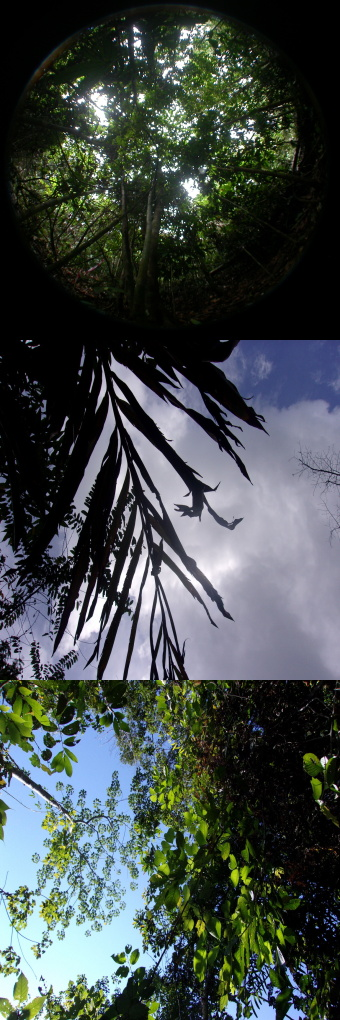

In [ ]:
preview_r = r"""
suppressMessages(library(magick))
raw_dir     <- system.file("images/canopy/raw",     package = "imageseg")
resized_dir <- system.file("images/canopy/resized", package = "imageseg")
mask_dir    <- system.file("images/canopy/masks",   package = "imageseg")
raw <- list.files(raw_dir, full.names = TRUE)
cat("raw images:", length(raw), "
"); print(basename(raw))
imgs <- image_read(raw)
print(image_info(imgs)[, c("format", "width", "height", "colorspace")])
dir.create("/content/outputs", showWarnings = FALSE, recursive = TRUE)
image_write(image_append(image_scale(imgs, "340x340!"), stack = TRUE),
            "/content/outputs/raw_contact_sheet.png")
res <- sort(list.files(resized_dir)); msk <- sort(list.files(mask_dir))
cat("resized images:", length(res), "->", paste(res, collapse = ", "), "
")
cat("masks:", length(msk), "->", paste(msk, collapse = ", "), "
")
info <- image_info(image_read(file.path(resized_dir, res[1])))
cat("resized dimensions:", info$width, "x", info$height, info$colorspace, "
")
"""
from pathlib import Path
Path("/content/preview_r.R").write_text(preview_r)
import subprocess
subprocess.run(["Rscript", "/content/preview_r.R"], check=True, timeout=1200)

from IPython.display import Image
Image(filename="/content/outputs/raw_contact_sheet.png", width=360)

### Author's workflow (vignette Part 1) on the 3 raw images / 著者のワークフローを raw 画像に実行

Runs the **author's exact inference chain** — `resizeImages` (256×256, `type="canopy"`) → `loadImages` → `imagesToKerasInput` (0–1 scaled RGB arrays) → `loadModel` (hdf5 with the training-time custom objects) → `imageSegmentation` — and prints `results$summary`. Per the package documentation, `predicted` is the sky fraction and `not_predicted` is the canopy density. The 3-panel `examples` images (input | probability | binary mask) are written to PNGs. 論文ビネット Part 1 と同じ一連の著者関数をそのまま実行し、summary と 3 枚組の予測画像を保存します。

In [ ]:
vignette_r = r"""
RET_PY <- trimws(readLines("/content/reticulate_python.txt", warn = FALSE)[1])
Sys.setenv(RETICULATE_PYTHON = RET_PY)
suppressMessages({library(imageseg); library(keras)})

wd_images_to_resize <- system.file("images/canopy/raw", package = "imageseg")
wd_images_to_classify <- "/content/canopy/resized_vignette"
unlink(wd_images_to_classify, recursive = TRUE)

resizeImages(imageDir = wd_images_to_resize, type = "canopy", outDir = wd_images_to_classify)

images <- loadImages(imageDir = wd_images_to_classify)
x <- imagesToKerasInput(images)
cat("model input array:", paste(dim(x), collapse = " x "), "(images x height x width x channels)\n")

model <- loadModel(modelFile = "/content/models/imageseg_canopy_model.hdf5")

results <- imageSegmentation(model = model, x = x)
cat("result slots:", paste(names(results), collapse = ", "), "\n")
print(results$summary)
write.csv(results$summary, "/content/outputs/vignette_summary.csv", row.names = FALSE)
# results$examples holds the package's own classification grids (columns: input |
# probability | binary; inputs stacked in chunks of 8). Subset frames with [ , not [[
# (which would strip the magick-image class).
n_ex <- length(results$examples)
for (i in seq_len(n_ex)) {
  magick::image_write(results$examples[i], sprintf("/content/outputs/vignette_example_%02d.png", i))
}
cat("wrote", n_ex, "example grids\n")
"""
from pathlib import Path
Path("/content/vignette_r.R").write_text(vignette_r)
import subprocess
p = subprocess.run(["Rscript", "/content/vignette_r.R"], capture_output=True, text=True, timeout=2400)
print(p.stdout[-6000:]); print(p.stderr[-3000:])
p.check_returncode()


  |                                                                            
  |                                                                      |   0%
  |                                                                            
  |=======================                                               |  33%
  |                                                                            
  |===============================================                       |  67%
  |                                                                            
  |======================================================================| 100%
model input array: 3 x 256 x 256 x 3 (images x height x width x channels)

1/1 [==============================] - 3s 3s/step
result slots: image, prediction, prediction_binary, examples, summary 
                                                       filename format width
1 /content/canopy/resized_vignette/canopy_example_hemi_raw1.tif   JPEG   256
2      /c

### Vignette run outputs / ビネット実行の結果画像

Displays the classification grids produced by the author's `imageSegmentation` (columns: resized input | model prediction as probabilities — grey = uncertainty | binary mask; one row per image, chunked in groups of 8). These are rendered by the package's own code in this VM. `imageSegmentation` が出力した分類グリッド（列: 入力 | 予測確率 | 2値マスク）を表示します。

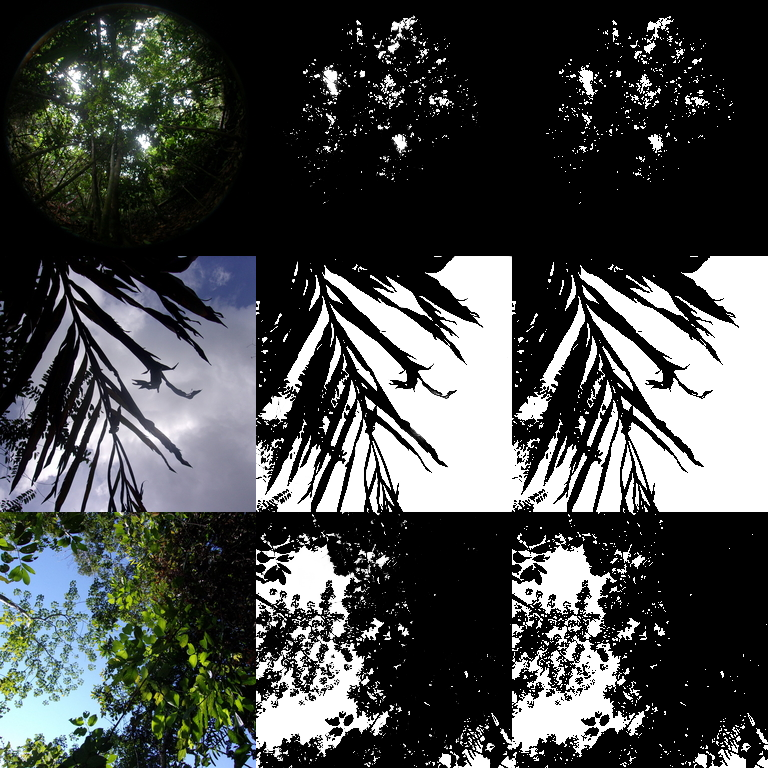

In [ ]:
import glob
from IPython.display import Image, display
for f in sorted(glob.glob("/content/outputs/vignette_example_*.png")):
    display(Image(filename=f, width=760))

### Our plausibility check: prediction vs author's hand masks (11 images) / 独自の妥当性チェック（著者マスクとの Dice）

**Our own check, not the paper's evaluation.** Predicts on the 11 pre-resized 256×256 images bundled in the package, aligns them with the 11 author-supplied masks **by numeric file name** (alphabetical order would pair `10_…` before `1_…` — a documented adaptation of our own, not a change to the author's computation), and computes the per-image **Dice coefficient** between the binary prediction and the mask. Both use the model's class-1 = **sky** convention. `sky_fraction_in_author_mask` vs `sky_fraction_predicted` makes the comparison transparent; the paper's reference value is canopy **Dice ≈ 0.91 on its held-out test set** (an 11-image spot check cannot verify that). A 3-column comparison panel (input | author mask | model prediction) is written for the first 4 images. 著者提供マスクと予測の Dice を 11 枚で計算します（ファイル名の数値順に対応付け。論文のテストセット精度の再現ではありません）。

In [ ]:
dice_r = r"""
RET_PY <- trimws(readLines("/content/reticulate_python.txt", warn = FALSE)[1])
Sys.setenv(RETICULATE_PYTHON = RET_PY)
suppressMessages({library(imageseg); library(keras); library(magick)})

resized_dir <- system.file("images/canopy/resized", package = "imageseg")
mask_dir    <- system.file("images/canopy/masks",   package = "imageseg")
images <- loadImages(imageDir = resized_dir)
masks  <- loadImages(imageDir = mask_dir)

# align image/mask pairs by the leading number of the file name
num <- function(f) as.integer(sub("[^0-9].*$", "", f))
ord_x <- order(num(list.files(resized_dir)))
ord_y <- order(num(list.files(mask_dir)))
images$img  <- images$img[ord_x]
masks$img   <- masks$img[ord_y]
if (!is.null(images$info)) images$info <- images$info[ord_x, ]
if (!is.null(masks$info))  masks$info  <- masks$info[ord_y, ]

x <- imagesToKerasInput(images)
y <- imagesToKerasInput(masks, type = "mask", grayscale = TRUE)
cat("input:", paste(dim(x), collapse = " x "), "| masks:", paste(dim(y), collapse = " x "), "\n")

model <- loadModel("/content/models/imageseg_canopy_model.hdf5")
pred <- model %>% predict(x)
pred_bin <- round(pred)   # author's binarization: >= 0.5 -> 1 (sky)

n <- dim(x)[1]
dice <- sapply(1:n, function(i) {
  p <- pred_bin[i, , , 1] == 1; m <- y[i, , , 1] == 1
  2 * sum(p & m) / (sum(p) + sum(m))
})
sky_pred <- round(apply(pred_bin[, , , 1], 1, mean), 3)
sky_mask <- round(apply(y[, , , 1], 1, mean), 3)
ids <- sort(num(list.files(resized_dir)))
df <- data.frame(image = paste0(ids, ".tif"),
                 dice_vs_author_mask = round(dice, 3),
                 sky_fraction_predicted = sky_pred,
                 sky_fraction_in_author_mask = sky_mask)
print(df)
write.csv(df, "/content/outputs/dice_check.csv", row.names = FALSE)
cat("mean Dice over", n, "images:", round(mean(dice), 3), "\n")

# comparison panel: input | author mask | model prediction (first 4 images)
# $img is a multi-frame magick image: subset frames with [ , not [[ (which strips the class)
make_row <- function(i) {
  inp <- image_scale(images$img[i], "256x256!")
  msk <- image_scale(masks$img[i], "256x256!")
  prd <- image_read(as.raster(pred_bin[i, , , 1]))
  image_append(c(inp, msk, prd), stack = FALSE)
}
panel <- image_append(image_join(lapply(1:4, make_row)), stack = TRUE)
image_write(panel, "/content/outputs/dice_panel_1to4.png")
"""
from pathlib import Path
Path("/content/dice_r.R").write_text(dice_r)
import subprocess
p = subprocess.run(["Rscript", "/content/dice_r.R"], capture_output=True, text=True, timeout=2400)
print(p.stdout[-6000:]); print(p.stderr[-3000:])
p.check_returncode()

input: 11 x 256 x 256 x 3 | masks: 11 x 256 x 256 x 1 

1/1 [==============================] - 7s 7s/step
    image dice_vs_author_mask sky_fraction_predicted
1   1.tif               0.907                  0.090
2   2.tif               0.589                  0.072
3   3.tif               0.871                  0.069
4   4.tif               0.993                  0.676
5   5.tif               0.959                  0.204
6   6.tif               0.968                  0.346
7   7.tif               0.995                  0.511
8   8.tif               0.942                  0.155
9   9.tif               0.996                  0.710
10 10.tif               0.893                  0.088
11 11.tif               0.901                  0.139
   sky_fraction_in_author_mask
1                        0.100
2                        0.030
3                        0.060
4                        0.683
5                        0.203
6                        0.369
7                        0.509
8         

### Input vs author mask vs model prediction / 入力・著者マスク・予測の比較

Displays the comparison panel for images 1–4 (left: resized input photograph; middle: the author's hand-drawn segmentation mask — white = sky per the model's class-1 convention; right: the model's binary prediction). This is the visual spot check behind the Dice table above. 左から「入力画像｜著者の手描きマスク｜モデル予測」。上の Dice 表に対応する視覚的なスポットチェックです。

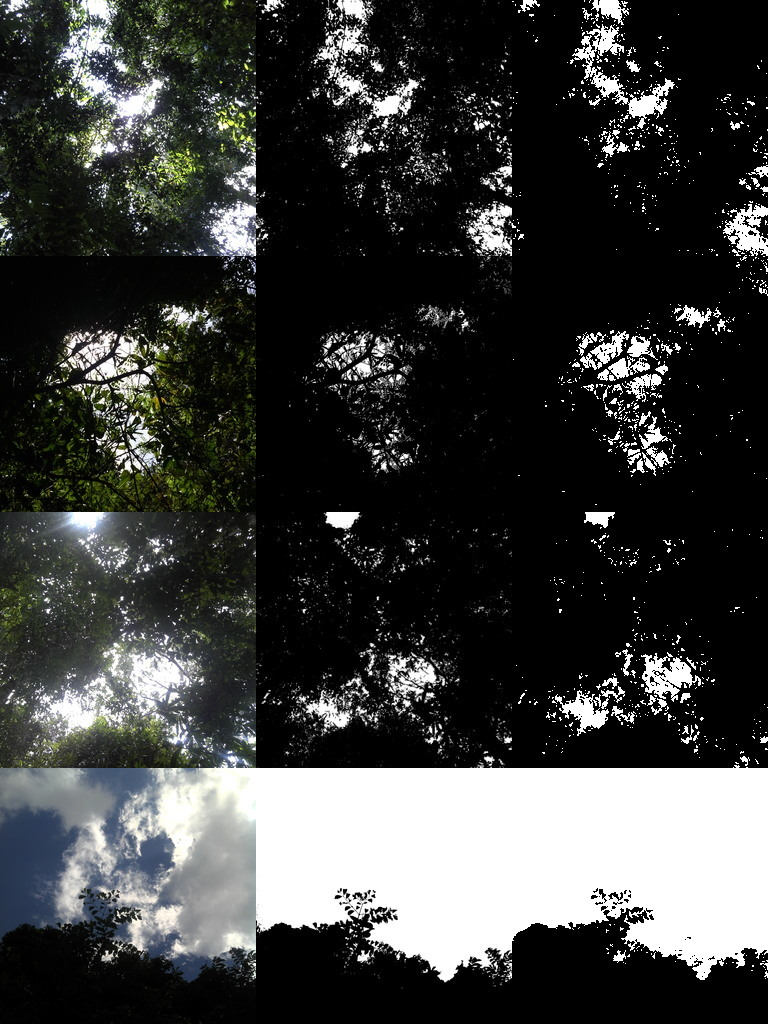

In [ ]:
from IPython.display import Image
Image(filename="/content/outputs/dice_panel_1to4.png", width=780)

### Results table and export / 結果表とエクスポート

Reloads the two CSVs written by the R steps (vignette summary; per-image Dice) as pandas tables for inspection, and copies them to the notebook working directory for optional download. The `not_predicted` column of the vignette summary is the **canopy density**; `dice_vs_author_mask` is our own spot-check metric. R 側で保存した 2 つの CSV を pandas で読み込み表示します（必要ならダウンロード可能な作業ディレクトリにもコピー）。

In [ ]:
import pandas as pd, shutil, pathlib

vign = pd.read_csv("/content/outputs/vignette_summary.csv")
dice = pd.read_csv("/content/outputs/dice_check.csv")
print("== vignette summary (3 raw images; predicted = sky fraction, not_predicted = canopy density) ==")
display(vign)
print("== per-image Dice vs author masks (11 pre-resized images) ==")
display(dice)

for f in ("vignette_summary.csv", "dice_check.csv"):
    shutil.copy(pathlib.Path("/content/outputs") / f, pathlib.Path("/content") / f)
print("CSV copies written to /content/")

== vignette summary (3 raw images; predicted = sky fraction, not_predicted = canopy density) ==


,filename,format,width,height,colorspace,matte,filesize,density,not_predicted,predicted
0,/content/canopy/resized_vignette/canopy_exampl...,JPEG,256,256,sRGB,False,78517,300x300,0.966,0.034
1,/content/canopy/resized_vignette/canopy_exampl...,JPEG,256,256,sRGB,False,81582,72x72,0.405,0.595
2,/content/canopy/resized_vignette/canopy_exampl...,JPEG,256,256,sRGB,False,112843,72x72,0.766,0.234


== per-image Dice vs author masks (11 pre-resized images) ==


,image,dice_vs_author_mask,sky_fraction_predicted,sky_fraction_in_author_mask
0,1.tif,0.907,0.090,0.100
1,2.tif,0.589,0.072,0.030
2,3.tif,0.871,0.069,0.060
3,4.tif,0.993,0.676,0.683
4,5.tif,0.959,0.204,0.203
5,6.tif,0.968,0.346,0.369
6,7.tif,0.995,0.511,0.509
7,8.tif,0.942,0.155,0.172
8,9.tif,0.996,0.710,0.714
9,10.tif,0.893,0.088,0.108


CSV copies written to /content/


## Interpretation, limitations, references / 解釈・限界・参照

**English**
- The vignette run applies the authors' pre-trained canopy model through their own functions; `results$summary` gives sky fraction (`predicted`) and canopy density (`not_predicted = 1 − predicted`) per image, matching the package documentation.
- The Dice table is **our own plausibility check** on 11 bundled images against the authors' hand-drawn masks; it says nothing about the paper's dataset-level accuracy (canopy Dice ≈ 0.91 on the held-out test set, paper p. 7) and is expected to differ (the bundled masks/images are part of the package's training material, so values here are likely *optimistic*).
- Out of scope: model training, the understory model, threshold-method comparison, and any dataset-level evaluation.

**日本語**
- 著者自身の関数で学習済み canopy モデルを実行し、`predicted`（空の割合）と `not_predicted`（canopy density）を summary として得ました。
- Dice 表は**本ノートブック独自の**スポットチェックであり、論文のデータセット精度（テストセット canopy Dice ≈ 0.91）の検証ではありません。同梱画像・マスクは学習素材の一部のため、値は楽観的になる可能性があります。

**References**
- Niedballa, J., Axtner, J. (2022). imageseg: An R package for deep learning-based image segmentation. *Methods in Ecology and Evolution* 13:2363–2371. https://doi.org/10.1111/2041-210X.13984
- Code: https://github.com/EcoDynIZW/imageseg (v0.5.2, commit `bba7a54c174308cc3800ad59568c9c928db74694`), also on CRAN.
- Models: Zenodo record 6861157 (https://doi.org/10.5281/zenodo.6861157).
- Vignette: *Introduction to 'imageseg'* (bundled with the package).